In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import os
import torch
import csv
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.integrate import cumulative_trapezoid
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
def load_data(dataset_root='../FORTH_TRACE_DATASET', save_path='all_data.npy'):
    # Se o arquivo já existe, lê direto
    if os.path.exists(save_path):
        print("A carregar os dados do arquivo salvo...")
        return np.load(save_path)
    
    print("A ler os dados do CSV...")
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)
    
    # Salva em .npy para carregar rápido na próxima vez
    np.save(save_path, data)
    print(f"Dados salvos em {save_path}")
    
    return data

# Usar a função
data = load_data()
print(data[:5])
# Carregar dados
data = np.load('all_data.npy')
print(data.shape) # ver dimensão (linhas, colunas)
print(data[:5]) # mostrar as primeiras 5 linhas

A carregar os dados do arquivo salvo...
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
(3930873, 13)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.013

## 1.1

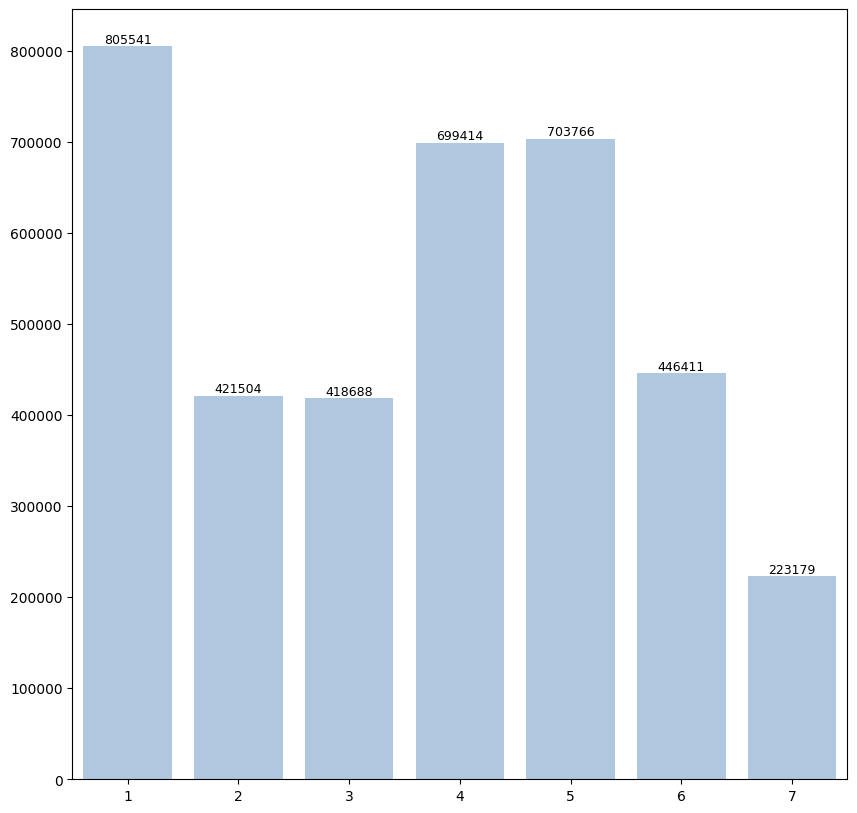

In [3]:
activity_labels = data[:, 12].astype(int)

# Filtrar apenas atividades 1 a 7
mask = (activity_labels >= 1) & (activity_labels <= 7)
data_filtered = data[mask]
filtered_labels = activity_labels[mask]

# Contar exemplos por atividade
atividades, contagens = np.unique(filtered_labels, return_counts=True)

# Plot com seaborn
plt.figure(figsize=(10,10))
grafico = sns.barplot(x=atividades, y=contagens, color='#A7C7E7')
grafico.bar_label(grafico.containers[0], fontsize=9)
plt.show()


## 1.2

In [4]:
def generate_smote_samples(X, y, activity_label, K, k_neighbors=5):

    current_count = np.sum(y == activity_label)
    target_count = current_count + K
    
    smote = SMOTE(
        sampling_strategy={activity_label: target_count},
        k_neighbors=k_neighbors
    )
    
    X_res, y_res = smote.fit_resample(X, y)
    dataset_augmented = np.hstack((X_res, y_res.reshape(-1,1)))
    return dataset_augmented


In [5]:
ignore_cols = [0, 1, 11, 12]
feature_cols = [i for i in range(data.shape[1]) if i not in ignore_cols]

df_norm = data.copy().astype(float)

scaler = StandardScaler()
df_norm[:, feature_cols] = scaler.fit_transform(data[:, feature_cols])

X = df_norm[:, feature_cols]          # apenas sensores
y = data[:, 12].astype(int)           # coluna do label

dataset_augmented = generate_smote_samples(X, y, activity_label=4, K=5)
print("Shape dataset_augmented:", dataset_augmented.shape)

Shape dataset_augmented: (3930878, 10)


## 1.3

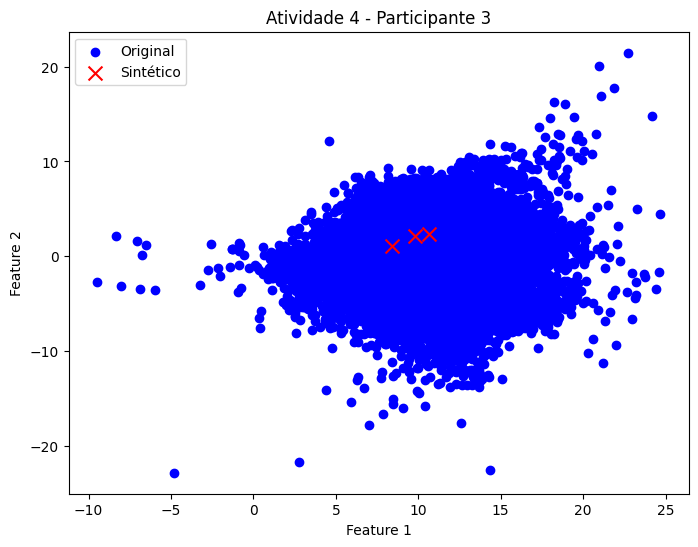

In [6]:
# Filtrar apenas participante 3
participant_id = 3
mask_participant = data[:, 0] == participant_id
data_participant = data[mask_participant]

# Separar features e label
feature_cols = list(range(2, 11))  # sensores
X_part = data_participant[:, feature_cols]
y_part = data_participant[:, 12].astype(int)

# Gerar 3 novas amostras para atividade 4
activity_label = 4
data_augmented = generate_smote_samples(X_part, y_part, activity_label=activity_label, K=3)

# --- 5. Separar exemplos ---
data_activity_original = data_participant[data_participant[:, 12] == activity_label]
num_original = data_activity_original.shape[0]

data_activity_augmented = data_augmented[data_augmented[:, -1] == activity_label]
original_samples = data_activity_augmented[:num_original]
synthetic_samples = data_activity_augmented[num_original:]

# Plotar o pedido
plt.figure(figsize=(8,6))
plt.scatter(original_samples[:, 1], original_samples[:, 2], color='blue', label='Original')
plt.scatter(synthetic_samples[:, 1], synthetic_samples[:, 2], color='red', label='Sintético', marker='x', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Atividade {activity_label} - Participante {participant_id}')
plt.legend()
plt.show()


-------------------------------------------------------------------------------

# Exercício 2 - Embedding Features

In [7]:
#codigo do stor do embedding 
def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder


def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target


def acc_segmentation(data):
  ''' Estract ACC segments and their activities '''

  TIMESTAMP_COL = 10
  MIN_SEGMENT_SIZE = 20
  fs_in_hz = 51.2
  win_size = 5000
  start_time = data[0,TIMESTAMP_COL]
  end_time = start_time + win_size

  activities = []
  segments = []

  while end_time < data[-1,TIMESTAMP_COL]:
    mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

    if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

      acc_xyz = data[mask,1:4]
      activity = data[mask, -1][0]
      
      activities.append(activity)
      segments.append( acc_xyz )
      

    start_time = end_time - win_size/2
    end_time = start_time + win_size
  
  
  return segments, activities



# load example file to test embedding
csv_file_path = '../FORTH_TRACE_DATASET/part13/part13dev1.csv'
 
csv_data = np.loadtxt(csv_file_path, delimiter=',')

original_segments, activities = acc_segmentation(csv_data)

resampled_segments = [resample_to_30hz_5s(segment, 51.2)[0] for segment in original_segments]

feature_encoder = load_model()

embeddings_list = []

# reshape segments to [n_segments, dimensions(xyz), time]
x_all = np.transpose( np.array(resampled_segments), (0, 2, 1) )
print(x_all.shape)

# iterate over the resampled segments and pass them 
#    through the model in batches to get the embeddings
batch_size = 5
with torch.no_grad():
    for i in range(0, x_all.shape[0], batch_size):
        xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
        eb = feature_encoder(xb)  # (B, D_embed)
        embeddings_list.append(eb.cpu().numpy())

embeddings = np.concatenate(embeddings_list, axis=0)
print(embeddings.shape)

Using cache found in C:\Users\bmsam/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
(369, 3, 150)
(369, 512, 1)


In [8]:
embeddings_list = []

base_path = '../FORTH_TRACE_DATASET'

for part_id in range(15):  # participantes de 0 a 14
    part_folder = os.path.join(base_path, f'part{part_id}')
    
    #todos os CSVs da pasta
    csv_files = sorted([f for f in os.listdir(part_folder) if f.endswith('.csv')])
    
    for csv_file in csv_files:
        csv_file_path = os.path.join(part_folder, csv_file)
        csv_data = np.loadtxt(csv_file_path, delimiter=',')
        
        # segmentar
        segments, activities = acc_segmentation(csv_data)
        
        # Filtrar apenas atividades 1 a 7
        segments_filtered = []
        participant_filtered = []
        activities_filtered= []
        for seg, act in zip(segments, activities):
            if 1 <= act <= 7:
                segments_filtered.append(seg)
                participant_filtered.append(part_id) 
                activities_filtered.append(act)

        if len(segments_filtered) == 0:
            continue
        
        # resample para 30Hz
        resampled_segments = [resample_to_30hz_5s(seg, 51.2)[0] for seg in segments_filtered]
        x_all = np.array([seg.T for seg in resampled_segments], dtype=np.float32)
        
        # extrair embeddings
        batch_size = 5
        with torch.no_grad():
            for i in range(0, x_all.shape[0], batch_size):
                xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
                eb = feature_encoder(xb)
                eb_np = eb.cpu().numpy()
                
                for j, seg_emb in enumerate(eb_np):
                    embeddings_list.append(
                        np.hstack([
                            participant_filtered[i+j],
                            activities_filtered[i+j],
                            seg_emb.flatten()
                        ])
                    )

# concatenar todos os participantes
embeddings_dataset = np.array(embeddings_list, dtype=np.float32)  
print(f"Shape final do embeddings_dataset (linhas x features+pid+atividade): {embeddings_dataset.shape}")

# exemplo
for pid in range(15):
    part_mask = embeddings_dataset[:,0] == pid
    part_data = embeddings_dataset[part_mask]
    if part_data.shape[0] == 0:
        continue
    print(f"Participante {pid} -> {part_data.shape[0]} segmentos")
    print("Exemplo de embedding (primeira linha, primeiras 10 dimensões):")
    print(part_data[0,:12]) 
    print("-"*30)

Shape final do embeddings_dataset (linhas x features+pid+atividade): (27699, 514)
Participante 0 -> 1846 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[0.         1.         0.         0.         0.         0.
 0.02860497 0.05294336 0.         0.04316683 0.         0.04375382]
------------------------------
Participante 1 -> 1844 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[1.         1.         0.         0.         0.         0.
 0.02128764 0.03353288 0.         0.04632877 0.         0.03986754]
------------------------------
Participante 2 -> 1847 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[2.         1.         0.         0.         0.         0.
 0.01461428 0.01896847 0.         0.0651965  0.         0.02664905]
------------------------------
Participante 3 -> 1849 segmentos
Exemplo de embedding (primeira linha, primeiras 10 dimensões):
[3.         1.         0.         0.         0.         0.
 

[participant_id, activity, embedding_1, embedding_2, ..., embedding_512]
como esta o dataset

---------------------------------

# Exercício 3 - Data splitting strategy

### 3.1

duvida: aqui é necessario que todas as atividades aparecam nos 3 conjuntos ou basta os participantes

# Feature Set

In [9]:
def create_windows(data, fs, window_length=5.0, overlap=0.5):
    n_samples_window = int(fs * window_length)
    step = int(n_samples_window * (1 - overlap))
    windows = []

    pessoas = np.unique(data[:, 0])

    for pessoa in pessoas:
        pessoa_data = data[data[:, 0] == pessoa]
        dispositivos = np.unique(pessoa_data[:, 1])

        for dispositivo in dispositivos:
            sub_data = pessoa_data[pessoa_data[:, 1] == dispositivo]
            n_samples = len(sub_data)

            # sliding windows normais
            for start_idx in range(0, n_samples - n_samples_window + 1, step):
                end_idx = start_idx + n_samples_window
                window_data = sub_data[start_idx:end_idx]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

            # incluir última janela incompleta
            if n_samples % step != 0:
                start_idx = n_samples - n_samples_window
                if start_idx < 0:
                    start_idx = 0
                window_data = sub_data[start_idx:]
                labels = window_data[:, 12]
                if np.all(labels == labels[0]):
                    windows.append(window_data)

    return windows
windows = create_windows(data, fs=51.2, window_length=5.0, overlap=0.5)
np.save("windows.npy", np.array(windows))

In [10]:
nomes_features = [
    'person_id',
    # ax
    'ax_mean','ax_median','ax_std','ax_var','ax_rms','ax_mean_derivative','ax_skewness','ax_kurtosis','ax_iqr','ax_zcr','ax_mcr',
    'ax_SpecEntropy','ax_DominantFreq','ax_Energy',
    # ay
    'ay_mean','ay_median','ay_std','ay_var','ay_rms','ay_mean_derivative','ay_skewness','ay_kurtosis','ay_iqr','ay_zcr','ay_mcr',
    'ay_SpecEntropy','ay_DominantFreq','ay_Energy',
    # az
    'az_mean','az_median','az_std','az_var','az_rms','az_mean_derivative','az_skewness','az_kurtosis','az_iqr','az_zcr','az_mcr',
    'az_SpecEntropy','az_DominantFreq','az_Energy',
    # gx
    'gx_mean','gx_median','gx_std','gx_var','gx_rms','gx_mean_derivative','gx_skewness','gx_kurtosis','gx_iqr','gx_zcr','gx_mcr',
    'gx_SpecEntropy','gx_DominantFreq','gx_Energy',
    # gy
    'gy_mean','gy_median','gy_std','gy_var','gy_rms','gy_mean_derivative','gy_skewness','gy_kurtosis','gy_iqr','gy_zcr','gy_mcr',
    'gy_SpecEntropy','gy_DominantFreq','gy_Energy',
    # gz
    'gz_mean','gz_median','gz_std','gz_var','gz_rms','gz_mean_derivative','gz_skewness','gz_kurtosis','gz_iqr','gz_zcr','gz_mcr',
    'gz_SpecEntropy','gz_DominantFreq','gz_Energy',
    # mx
    'mx_mean','mx_median','mx_std','mx_var','mx_rms','mx_mean_derivative','mx_skewness','mx_kurtosis','mx_iqr','mx_zcr','mx_mcr',
    'mx_SpecEntropy','mx_DominantFreq','mx_Energy',
    # my
    'my_mean','my_median','my_std','my_var','my_rms','my_mean_derivative','my_skewness','my_kurtosis','my_iqr','my_zcr','my_mcr',
    'my_SpecEntropy','my_DominantFreq','my_Energy',
    # mz
    'mz_mean','mz_median','mz_std','mz_var','mz_rms','mz_mean_derivative','mz_skewness','mz_kurtosis','mz_iqr','mz_zcr','mz_mcr',
    'mz_SpecEntropy','mz_DominantFreq','mz_Energy',

    # Features gerais
    'Corr_Acc_XY','Corr_Acc_XZ','Corr_Acc_YZ',
    'Corr_Gyr_XY','Corr_Gyr_XZ','Corr_Gyr_YZ',
    'Corr_Mag_XY','Corr_Mag_XZ','Corr_Mag_YZ',
    'MI_mean','MI_var',
    'SMA',
    'EVA_Acc_1','EVA_Acc_2',
    'Corr_Acc_Gravity_Heading',
    'AvgVelHeading','AvgVelGravity',
    'AvgRotAngleGravity',
    'AvgAccEnergy',
    'AvgRotEnergy',
    # incluir a label no final
    'label']

In [11]:
def calculate_features (windows):
        features = []
        labels= []
        fs= 51.2
        for window in windows:
                window_features = []
                window_label = window[0, 12]
                if window_label <= 7 and window_label >= 1:
                        pers_id = window[0, 0]
                        labels.append(window_label)

                        for col in range(2, 11):
                                coluna = window[:, col]
                                N = len(coluna)
                                mean_col = np.mean(coluna)

                                #temporal features
                                #média
                                window_features.append(mean_col)

                                #mediana
                                window_features.append(np.median(coluna))

                                #desvião padrão
                                window_features.append(np.std(coluna))

                                #variância
                                window_features.append(np.var(coluna))

                                #raíz quadrada da média  
                                window_features.append(np.sqrt(np.mean(coluna**2)))

                                #derivda média
                                window_features.append(np.mean(np.diff(coluna)))

                                #skewness
                                window_features.append(stats.skew(coluna))

                                #Kurtosis
                                window_features.append(stats.kurtosis(coluna)) 

                                #IQR
                                window_features.append(stats.iqr(coluna))

                                #zero crossing rate    
                                window_features.append(len (np.where(np.diff(np.sign(coluna)))[0])/N)

                                #mean corssing rate
                                window_features.append(len (np.where(np.diff(np.sign(coluna - mean_col)))[0])/N)

                                #spectral features ------------
                                fft_col = np.fft.rfft(coluna)
                                fft_energy = np.abs(fft_col)**2
                                fft_freqs = np.fft.rfftfreq(N, 1/fs)

                                #Spectral Entropy 
                                psd = fft_energy[1:]
                                psd_norm = psd / np.sum(psd)
                                spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))
                                window_features.append(spectral_entropy)

                                # Dominant Frequency
                                dominant_freq = fft_freqs[np.argmax(fft_energy)]
                                window_features.append(dominant_freq)

                                #Energy
                                energy = np.sum(psd) / N
                                window_features.append(energy)

                        #pairwise correlation----------
                        # Accelerometer correlations
                        acc = window[:, 2:5]
                        corr_acc = np.corrcoef(acc.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_acc)
                        # Gyroscope correlations
                        gyr = window[:, 5:8]
                        corr_gyr = np.corrcoef(gyr.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_gyr)
                        # Magnetometer correlations
                        mag = window[:, 8:11]
                        corr_mag = np.corrcoef(mag.T)[np.triu_indices(3, 1)]
                        window_features.extend(corr_mag)

                        #Movement intensity --> temporal
                        ax, ay, az = window[:, 2], window[:, 3], window[:, 4]
                        mi = np.sqrt(np.mean(ax**2) + np.mean(ay**2) + np.mean(az**2))
                        window_features.extend([np.mean(mi), np.var(mi)])

                        #normalized signal magnitude area (SMA) --> temporal
                        T = len(ax)
                        sma = (np.sum(np.abs(ax)) + np.sum(np.abs(ay)) + np.sum(np.abs(az))) / T
                        window_features.append(sma)

                        # EVA --> temporal
                        eva_acc = np.sort(np.linalg.eigvals(np.cov(window[:, 2:5] - np.mean(window[:, 2:5], axis=0), rowvar=False)))[::-1][:2]
                        window_features.extend(eva_acc)

                        # Correlation between Acceleration along Gravity and Heading Directions --> temporal
                        a_heading = np.sqrt(ay**2 + az**2)
                        window_features.append(np.corrcoef(ax, a_heading)[0, 1])

                        # Averaged Velocity along Gravity Direction --> temporal
                        t = window[:, 11]
                        vy = cumulative_trapezoid(ay, t, initial=0)
                        vz = cumulative_trapezoid(az, t, initial=0)
                        vx = cumulative_trapezoid(ax, t, initial=0)
                        avh = np.sqrt(np.mean(vy)**2 + np.mean(vz)**2)
                        avg = np.mean(vx)
                        window_features.extend([avh, avg])

                        # Averaged Rotation Angle along Gravity Direction --> temporal
                        gx = window[:, 5]
                        theta_x = cumulative_trapezoid(gx, t, initial=0)
                        window_features.append(np.mean(theta_x))

                        # Averaged Acceleration Energy --> spectral
                        acc_block = window[:, 2:5]  # ax, ay, az
                        fft_acc = np.fft.rfft(acc_block, axis=0)
                        energy_acc = np.sum((np.abs(fft_acc)**2)[1:, :], axis=0) / acc_block.shape[0]
                        AEE = np.mean(energy_acc)
                        window_features.append(AEE)

                        # Averaged Rotation Energy --> spectral
                        gyr_block = window[:, 5:8]  # gx, gy, gz
                        fft_gyr = np.fft.rfft(gyr_block, axis=0)
                        energy_gyr = np.sum((np.abs(fft_gyr)**2)[1:, :], axis=0) / gyr_block.shape[0]
                        ARE = np.mean(energy_gyr)
                        window_features.append(ARE)

                        features.append([pers_id] + window_features)
        feature_set_with_labels = np.column_stack((features, labels)) 
        return feature_set_with_labels
#feature_set = calculate_features(windows)

In [12]:
#features = pd.DataFrame(feature_set, columns=nomes_features)
#features.to_csv('features_dataset.csv', header=nomes_features, index=False)
feature_dataset = pd.read_csv('features_dataset.csv').to_numpy()

print("Shape do FEATURE DATASET (atividades 1 a 7):", feature_dataset.shape)
print(feature_dataset[:5])

participants_data = {}
for part_id in range(15):
    part_rows = feature_dataset[feature_dataset[:, 0] == part_id]
    if len(part_rows) > 0:
        participants_data[part_id] = part_rows

for pid, pdata in participants_data.items():
    print(f"Participante {pid} -> {pdata.shape[0]} linhas")
    
    
# quais têm dados 
print("Participantes com dados:", list(participants_data.keys()))
print("Número de participantes com dados:", len(participants_data))

Shape do FEATURE DATASET (atividades 1 a 7): (27918, 148)
[[ 0.00000000e+00 -1.71878555e+00 -1.71330000e+00  8.88482084e-02
   7.89400413e-03  1.72108040e+00  4.54117647e-04 -2.86346009e-01
   1.92488234e-01  1.04025000e-01  0.00000000e+00  1.25000000e-01
   4.53747721e+00  0.00000000e+00  1.01056507e+00  9.36300859e+00
   9.37530000e+00  6.63270502e-02  4.39927758e-03  9.36324352e+00
   1.29019608e-04 -7.69729438e-01  1.35445619e-01  9.02000000e-02
   0.00000000e+00  1.87500000e-01  4.18512947e+00  0.00000000e+00
   5.63211211e-01  2.53714180e+00  2.47070000e+00  1.52909124e-01
   2.33812002e-02  2.54174540e+00 -6.33333333e-04  7.61732179e-01
  -8.32688693e-01  2.71050000e-01  0.00000000e+00  6.64062500e-02
   2.04689830e+00  0.00000000e+00  2.99280106e+00 -9.42287738e-01
  -8.52360000e-01  1.95766030e+00  3.83243383e+00  2.17263435e+00
  -9.11372549e-04 -1.68788998e+00  5.54697476e+00  1.70152300e+00
   6.25000000e-02  1.09375000e-01  2.91599912e+00  0.00000000e+00
   4.90555600e+02 

In [13]:
# features
features_train_list = []
features_val_list = []
features_test_list = []

for id_p, pdata in participants_data.items():
    # 1º split
    train, temp = train_test_split(pdata, test_size=0.4, random_state=42, shuffle=True)
    # Use a TVT split of 60%-20%-20% split, within each subject (data of a single subject is present in all sets)
    # 2º split
    val, test = train_test_split(temp, test_size=0.5, random_state=42, shuffle=True)
    
    features_train_list.append(train)
    features_val_list.append(val)
    features_test_list.append(test)

# concatena todos os participantes
features_train = np.vstack(features_train_list)
features_val = np.vstack(features_val_list)
features_test = np.vstack(features_test_list)

print("FEATURES TRAIN:", features_train.shape)
print("FEATURES VAL:", features_val.shape)
print("FEATURES TEST:", features_test.shape)



print("-------")

# embeddings
emb_train_list = []
emb_val_list = []
emb_test_list = []

for pid in range(15):
    part_mask = embeddings_dataset[:,0] == pid
    part_data = embeddings_dataset[part_mask]
    
    train_x, temp_x = train_test_split(part_data, test_size=0.4, random_state=42, shuffle=True)
    val_x, test_x = train_test_split(temp_x, test_size=0.5, random_state=42, shuffle=True)
    
    emb_train_list.append(train_x)
    emb_val_list.append(val_x)
    emb_test_list.append(test_x)

# concatena todos os participantes
emb_train = np.concatenate(emb_train_list, axis=0)
emb_val = np.concatenate(emb_val_list, axis=0)
emb_test = np.concatenate(emb_test_list, axis=0)

print("EMBEDDINGS TRAIN:", emb_train.shape)
print("EMBEDDINGS VAL:", emb_val.shape)
print("EMBEDDINGS TEST:", emb_test.shape)


FEATURES TRAIN: (16744, 148)
FEATURES VAL: (5585, 148)
FEATURES TEST: (5589, 148)
-------
EMBEDDINGS TRAIN: (16613, 514)
EMBEDDINGS VAL: (5539, 514)
EMBEDDINGS TEST: (5547, 514)


In [14]:
# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES TRAIN (primeiras 5 linhas)")
print(features_train[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS TRAIN (primeiras 5 linhas)")
print(emb_train[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES VALID (primeiras 5 linhas)")
print(features_val[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS VALID (primeiras 5 linhas)")
print(emb_val[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

# Mostrar primeiras 5 linhas do FEATURES TRAIN
print("FEATURES TEST (primeiras 5 linhas)")
print(features_test[:5])
print("-"*30)

# Mostrar primeiras 5 linhas do EMBEDDINGS TRAIN
print("EMBEDDINGS TEST (primeiras 5 linhas)")
print(emb_test[:5, :12])  # PID, atividade + primeiras 10 dimensões
print("-"*30)

FEATURES TRAIN (primeiras 5 linhas)
[[ 0.00000000e+00  2.26835754e+00  2.03255000e+00  5.16674555e+00
   2.66952596e+01  5.64275691e+00 -1.02227451e-02 -8.79669399e-02
   5.50618459e+00  4.19365250e+00  1.13281250e-01  1.79687500e-01
   6.09737180e+00  0.00000000e+00  3.43457504e+03  9.51450832e+00
   9.63960000e+00  4.43062829e+00  1.96304670e+01  1.04955388e+01
  -1.96094118e-02 -4.30568126e-01  1.77855403e+00  3.54057500e+00
   1.56250000e-02  1.91406250e-01  5.03817038e+00  0.00000000e+00
   2.51510935e+03 -4.87944468e-01 -1.16865000e+00  3.21517398e+00
   1.03373437e+01  3.25198917e+00  6.92549020e-04  1.08899311e+00
   2.33771029e+00  3.31282500e+00  1.32812500e-01  1.71875000e-01
   5.81645244e+00  6.00000000e-01  1.33039768e+03  9.46786879e+00
   5.18980000e+00  5.68081248e+01  3.22716304e+03  5.75916971e+01
   6.02605490e-01  2.53774369e-01  9.93957334e-02  6.02010000e+01
   8.98437500e-02  6.64062500e-02  3.92432013e+00  1.40000000e+00
   4.13149015e+05  4.25762099e+01  2.609

### 3.2

In [15]:
all_participants = np.arange(15)

#para ser aleatorio
np.random.seed(42) 
shuffled = np.random.permutation(all_participants)

train_participants = shuffled[:9]
val_participants   = shuffled[9:12]
test_participants  = shuffled[12:]
print("Treino (features & embeddings):", train_participants)
print("Validação (features & embeddings):", val_participants)
print("Teste (features & embeddings):", test_participants)


def filter_by_participants(dataset, participants):
    mask = np.isin(dataset[:, 0], participants)
    return dataset[mask]

# feature
features_train_subj = filter_by_participants(feature_dataset, train_participants)
features_val_subj   = filter_by_participants(feature_dataset, val_participants)
features_test_subj  = filter_by_participants(feature_dataset, test_participants)

print("\n------")
print("FEATURES TRAIN:", features_train_subj.shape)
print("FEATURES VAL  :", features_val_subj.shape)
print("FEATURES TEST :", features_test_subj.shape)



#embeddings
emb_train_subj = filter_by_participants(embeddings_dataset, train_participants)
emb_val_subj   = filter_by_participants(embeddings_dataset, val_participants)
emb_test_subj  = filter_by_participants(embeddings_dataset, test_participants)

print("\n------")
print("EMBEDDINGS TRAIN:", emb_train_subj.shape)
print("EMBEDDINGS VAL  :", emb_val_subj.shape)
print("EMBEDDINGS TEST :", emb_test_subj.shape)

Treino (features & embeddings): [ 9 11  0 13  5  8  2  1 14]
Validação (features & embeddings): [ 4  7 10]
Teste (features & embeddings): [12  3  6]

------
FEATURES TRAIN: (16763, 148)
FEATURES VAL  : (5471, 148)
FEATURES TEST : (5684, 148)

------
EMBEDDINGS TRAIN: (16545, 514)
EMBEDDINGS VAL  : (5565, 514)
EMBEDDINGS TEST : (5589, 514)


In [16]:
# Features
print("FEATURES TRAIN (primeiras 5 linhas)")
print(features_train_subj[:5])
print("------------------------------")

print("FEATURES VAL (primeiras 5 linhas)")
print(features_val_subj[:5])
print("------------------------------")

print("FEATURES TEST (primeiras 5 linhas)")
print(features_test_subj[:5])
print("------------------------------")

# Embeddings
print("EMBEDDINGS TRAIN (primeiras 5 linhas)")
print(emb_train_subj[:5])
print("------------------------------")

print("EMBEDDINGS VAL (primeiras 5 linhas)")
print(emb_val_subj[:5])
print("------------------------------")

print("EMBEDDINGS TEST (primeiras 5 linhas)")
print(emb_test_subj[:5])
print("------------------------------")


FEATURES TRAIN (primeiras 5 linhas)
[[ 0.00000000e+00 -1.71878555e+00 -1.71330000e+00  8.88482084e-02
   7.89400413e-03  1.72108040e+00  4.54117647e-04 -2.86346009e-01
   1.92488234e-01  1.04025000e-01  0.00000000e+00  1.25000000e-01
   4.53747721e+00  0.00000000e+00  1.01056507e+00  9.36300859e+00
   9.37530000e+00  6.63270502e-02  4.39927758e-03  9.36324352e+00
   1.29019608e-04 -7.69729438e-01  1.35445619e-01  9.02000000e-02
   0.00000000e+00  1.87500000e-01  4.18512947e+00  0.00000000e+00
   5.63211211e-01  2.53714180e+00  2.47070000e+00  1.52909124e-01
   2.33812002e-02  2.54174540e+00 -6.33333333e-04  7.61732179e-01
  -8.32688693e-01  2.71050000e-01  0.00000000e+00  6.64062500e-02
   2.04689830e+00  0.00000000e+00  2.99280106e+00 -9.42287738e-01
  -8.52360000e-01  1.95766030e+00  3.83243383e+00  2.17263435e+00
  -9.11372549e-04 -1.68788998e+00  5.54697476e+00  1.70152300e+00
   6.25000000e-02  1.09375000e-01  2.91599912e+00  0.00000000e+00
   4.90555600e+02 -5.43982020e-01 -3.313

VER MELHOR ISTO

*features_dataset*
as colunas representam : 
- coluna 0: ID do participante
- Coluna 1: device ID 
- coluna 2 a 11: valores das features
- coluna 12: timestamp
- coluna 13: label da atividade


*embeddings_dataset*
- Coluna 0: participant_id
- Coluna 1: activity (label)
- Colunas 2 a 513: embeddings (512 dimensões)

### 3.3

No 3.1 cada participante contribui com dados de treino, validação e teste.
- Ou seja, cada participante está dividido em dados de treino, validação e teste. 
- Isto pode fazer com que o modelo aprenda padrões individuais daquele participante  

No 3.2 cada participante só está num dos conjuntos de dados: ou no de teste, ou de treino ou de validação.
- O modelo aqui não conhece padrões especificos de cada participante e por isso se calhar esta estratégia é mais realista



A melhor estratégia para ser aplicada aos novos participantes é então a 2º porque o modelo ainda não viu dados do mesmo individuo e consegue generalizar para novos participantes.

### 3.4. 
Prepare your pipeline in a way that, after the split, for each dataset, you can compute and transform each set into three different scenarios:
1. All features/embeddings dataset
2. PCA-reduced features/embeddings dataset (keeping just the components
that explain 90% of the variance)
3. Feature-selected features/embeddings (keeping just the top 15 features
selected by the ReliefF method).

#### a)

In [28]:
# Exercício 3.1 (60% train -20% val -20% test split)

# --- Features com split por 60-20-20 ---
X_feat_train_all = features_train[:, 1:-1]  # features (exceto pid e label)
y_feat_train_all = features_train[:, -1].astype(int)    # label
X_feat_val_all = features_val[:, 1:-1]
y_feat_val_all = features_val[:, -1].astype(int)
X_feat_test_all = features_test[:, 1:-1]
y_feat_test_all = features_test[:, -1].astype(int)
# --- Embeddings com split por 60-20-20 ---
X_emb_train_all = emb_train[:, 2:]  # todas as features exceto individuo
y_emb_train_all = emb_train[:, 1].astype(int)    # label
X_emb_val_all = emb_val[:, 2:]
y_emb_val_all = emb_val[:, 1].astype(int)
X_emb_test_all = emb_test[:, 2:]
y_emb_test_all = emb_test[:, 1].astype(int)

# Exercício 3.2 (split por subject (9 train, 3 val, 3 test))

# --- Features com split por subject ---
X_feat_train_subj = features_train_subj[:, 1:-1]  # todas as features exceto individuo e label
y_feat_train_subj = features_train_subj[:, -1].astype(int)    # label
X_feat_val_subj = features_val_subj[:, 1:-1]
y_feat_val_subj = features_val_subj[:, -1].astype(int)
X_feat_test_subj = features_test_subj[:, 1:-1]
y_feat_test_subj = features_test_subj[:, -1].astype(int)
# --- Embeddings com split por subject ---
X_emb_train_subj = emb_train_subj[:, 2:]  # todas as features exceto individuo e label
y_emb_train_subj = emb_train_subj[:, 1].astype(int)    # label
X_emb_val_subj = emb_val_subj[:, 2:]
y_emb_val_subj = emb_val_subj[:, 1].astype(int)
X_emb_test_subj = emb_test_subj[:, 2:]
y_emb_test_subj = emb_test_subj[:, 1].astype(int)

## para o exercicio 3.2

#### b)

In [30]:
def apply_pca(X_train, X_val, X_test, variance_threshold=0.90):
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)
    
    print(f"PCA - Número de componentes mantidos: {pca.n_components_}")
    return X_train_pca, X_val_pca, X_test_pca

In [32]:
print ("-- 3.1 --")
# Features
X_feat_train_pca, X_feat_val_pca, X_feat_test_pca = apply_pca(X_feat_train_all, X_feat_val_all, X_feat_test_all)
# Embeddings
X_emb_train_pca, X_emb_val_pca, X_emb_test_pca = apply_pca(X_emb_train_all, X_emb_val_all, X_emb_test_all)

# Mostrar shapes PCA
print("FEATURES TRAIN PCA w 602020:", X_feat_train_pca.shape)
print("EMBEDDINGS TRAIN PCA w 602020:", X_emb_train_pca.shape)

print("-- 3.2 --")

X_feat_train_subj_pca, X_feat_val_subj_pca, X_feat_test_subj_pca = apply_pca(X_feat_train_subj, X_feat_val_subj, X_feat_test_subj)
# Embeddings
X_emb_train_subj_pca, X_emb_val_subj_pca, X_emb_test_subj_pca = apply_pca(X_emb_train_subj, X_emb_val_subj, X_emb_test_subj)

# Mostrar shapes PCA
print("FEATURES TRAIN PCA w subj:", X_feat_train_subj_pca.shape)
print("EMBEDDINGS TRAIN PCA w subj:", X_emb_train_subj_pca.shape)

-- 3.1 --
PCA - Número de componentes mantidos: 2
PCA - Número de componentes mantidos: 1
FEATURES TRAIN PCA w 602020: (16744, 2)
EMBEDDINGS TRAIN PCA w 602020: (16613, 1)
-- 3.2 --
PCA - Número de componentes mantidos: 2
PCA - Número de componentes mantidos: 1
FEATURES TRAIN PCA w subj: (16763, 2)
EMBEDDINGS TRAIN PCA w subj: (16545, 1)


#### c)

In [34]:
def reliefF_select(X, y, n_neighbors=10, n_features_select=15, 
                              random_state=42, sample_size=5000):
    """
    Aplica ReliefF no X e y (já separados) e retorna as n_features_select mais importantes.
    
    Parâmetros:
    - dataset: numpy array com coluna 0 = individuo, última coluna = label
    - n_neighbors: número de vizinhos para ReliefF
    - n_features_select: número de features a retornar
    - random_state: para reprodutibilidade
    - sample_size: número de exemplos a usar para calcular ReliefF (para não explodir memória)
    
    Retorna:
    - reduced_df: DataFrame com top features + individuo + label
    - selected_columns: lista dos nomes das features selecionadas
    - weights: vetor de pesos das features originais
    """
    np.random.seed(random_state)
    n_samples, n_features = X.shape
    
    # --- amostragem para grandes datasets ---
    if n_samples > sample_size:
        idx = np.random.choice(n_samples, sample_size, replace=False)
        X_sample, y_sample = X[idx], y[idx]
    else:
        X_sample, y_sample = X, y
    
    n_samples_sample = X_sample.shape[0]
    weights = np.zeros(n_features)
    
    # ReliefF: percorre exemplos aleatórios da amostra
    for _ in range(n_samples_sample):
        i = np.random.randint(0, n_samples_sample)
        xi, yi = X_sample[i], y_sample[i]
        
        same_class = np.where(y_sample == yi)[0]
        diff_class = np.where(y_sample != yi)[0]
        
        same_dists = np.sum((X_sample[same_class] - xi)**2, axis=1)
        diff_dists = np.sum((X_sample[diff_class] - xi)**2, axis=1)
        
        near_hits_idx = same_class[np.argsort(same_dists)[1:n_neighbors+1]]
        near_misses_idx = diff_class[np.argsort(diff_dists)[:n_neighbors]]
        
        near_hits = X_sample[near_hits_idx]
        near_misses = X_sample[near_misses_idx]
        
        for j in range(n_features):
            hit_term = np.sum((xi[j] - near_hits[:, j])**2) / n_neighbors
            miss_term = np.sum((xi[j] - near_misses[:, j])**2) / n_neighbors
            weights[j] += miss_term - hit_term
    
    weights /= n_samples_sample
    selected_indices = np.argsort(weights)[::-1][:n_features_select]
    
    return selected_indices, weights


In [35]:
def apply_relieff_pipeline(X_train, y_train, X_val, X_test, n_features_select=15):
    """Aplica ReliefF: calcula no train, aplica em todos"""
    selected_indices, weights = reliefF_select(X_train, y_train, n_features_select=n_features_select)
    
    X_train_relief = X_train[:, selected_indices]
    X_val_relief = X_val[:, selected_indices]
    X_test_relief = X_test[:, selected_indices]
    
    print(f"ReliefF - Top {n_features_select} features selecionadas")
    return X_train_relief, X_val_relief, X_test_relief, selected_indices


3.1

In [36]:
# --- 3.1 (60-20-20) ---
X_feat_train_relief, X_feat_val_relief, X_feat_test_relief, feat_indices = apply_relieff_pipeline(
    X_feat_train_all, y_feat_train_all, X_feat_val_all, X_feat_test_all
)
X_emb_train_relief, X_emb_val_relief, X_emb_test_relief, emb_indices = apply_relieff_pipeline(
    X_emb_train_all, y_emb_train_all, X_emb_val_all, X_emb_test_all
)

# --- 3.2 (por subject 9-3-3) ---
X_feat_train_subj_relief, X_feat_val_subj_relief, X_feat_test_subj_relief, feat_indices_subj = apply_relieff_pipeline(
    X_feat_train_subj, y_feat_train_subj, X_feat_val_subj, X_feat_test_subj
)
X_emb_train_subj_relief, X_emb_val_subj_relief, X_emb_test_subj_relief, emb_indices_subj = apply_relieff_pipeline(
    X_emb_train_subj, y_emb_train_subj, X_emb_val_subj, X_emb_test_subj
)

ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas
ReliefF - Top 15 features selecionadas


-------------------------------------------------------------------------------

## 4 - Model learning
We will now train a model to automatically classify the activity of each segment. We will use k-Nearest Neighbors.

### 4.1
Implement a k-Nearest Neighbors classifier (we expect you to implement your own version, but then you can use the sci-kit learn version if you need better performance. See information in [sklearn_KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)).

In [ ]:
# Each line is a segment (window of 5 seconds with 50% overlap)
# Inside each windows the first index is a window, second is a column (variable) and each window contains x lines from the original dataset.

class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y têm de ser igual.")
        
    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))
    
    def predict(self, X):
        X_test = np.array(X)
        predictions = []

        for test_point in X_test:
            # Calcukar distâncias para todos os pontos de treino
            distances = np.linalg.norm(self.X_train - test_point, axis=1)
            # Obter os índices dos k vizinhos mais próximos
            k_indices = np.argsort(distances)[:self.k]
            # Obter as labels dos k vizinhos
            k_nearest_labels = self.y_train[k_indices]
            # Aprovar por maioria
            most_common = np.bincount(k_nearest_labels.astype(int)).argmax()
            predictions.append(most_common)

        return np.array(predictions)

class KNNClassifierGPU:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
        # Deteta se há GPU disponível, caso contrário usa CPU
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def fit(self, X, y):
        # Converte os dados para tensores e envia para a GPU
        # X(distancia entre pontos) = float & y(classes) = long/int
        self.X_train = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.y_train = torch.tensor(y, dtype=torch.long).to(self.device)
        
        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y tem de ser igual.")

    def predict(self, X):
        # Enviar os dados de teste para a Gráfica
        X_test = torch.tensor(X, dtype=torch.float32).to(self.device)

        # --- Calcular distâncias ---
        # Utilizar o cdist para calcular a matriz de distâncias NxM. (+ rápido que um loop)
        # p=2 para a distância euclidiana
        # dists = (num_test_samples, num_train_samples)
        dists = torch.cdist(X_test, self.X_train, p=2)

        # --- Obter os índices dos k vizinhos mais próximos ---
        # topk retorna os maiores valores
        # largest=False para ter as menores distâncias
        # dim = 1 porque queremos os vizinhos para cada amostra de teste
        knns = dists.topk(self.k, largest=False, dim=1)
        knn_indices = knns.indices

        # --- Obter as labels dos k vizinhos ---
        # Ir buscar as classes correspondentes ao y_train através dos índices
        # neighbor_labels shape = (num_test_samples, k)
        neighbor_labels = self.y_train[knn_indices]

        # --- Aprovar por maioria (Votação) ---
        # torch.mode retorna o valor mais frequente em cada linha
        # (values, indices) = torch.mode(...)
        predictions, _ = torch.mode(neighbor_labels, dim=1)

        # Devolve para o CPU e converte para numpy array (para manter compatibilidade)
        return predictions.cpu().numpy()

# Usar
#gpu_knn = KNNClassifierGPU(k=5)
#gpu_knn.fit(X_train, y_train)
#y_pred = gpu_knn.predict(X_test)

### 4.2
Create a function that receives two lists of values: the true labels and predicted labels, and returns a set of classification metrics: confusion matrix, accuracy, f1 score, precision, recall, etc.

In [ ]:
def evaluate_model(labels_set, y_pred):
    print(metrics.classification_report(labels_set, y_pred))
    print(metrics.confusion_matrix(labels_set, y_pred))

KNN a correr em: cpu
Avaliação do modelo KNN (Features com split por subject):
              precision    recall  f1-score   support

           1       0.61      0.80      0.69      1201
           2       0.51      0.43      0.47       658
           3       0.49      0.32      0.39       663
           4       0.40      0.44      0.42      1086
           5       0.40      0.42      0.41      1081
           6       0.47      0.45      0.46       662
           7       0.22      0.10      0.13       333

    accuracy                           0.48      5684
   macro avg       0.44      0.42      0.42      5684
weighted avg       0.47      0.48      0.47      5684

[[964 143  84   4   6   0   0]
 [237 286 133   1   1   0   0]
 [319 133 210   0   1   0   0]
 [ 25   2   0 483 420 126  30]
 [ 31   0   0 453 457 100  40]
 [  0   0   0 169 153 295  45]
 [  0   0   0  85 107 109  32]]
KNN a correr em: cpu
Avaliação do modelo KNN (Embeddings com split por subject):
              precision  

-------------------------------------------------------------------------------

## 5 - Model evaluation
For each splitting strategy (2) applied for the 3 versions (all feats, PCA feats, ReliefF feats) of the 2 datasets (features, embeddings), train the classifier and evaluate its results:

### 5.1 Hyperparameter tuning
Select the best value of k using only the train and validation data. Then, with the best k, retrain with the dataset (train + validation) and evaluate on the test set.

### 5.2 Report and analyse results
Check the confusion matrices and observe which activities are harder to classify. Which dataset worked best (features vs embeddings)? Did feature selection improve the performance? Etc.

### 5.3 Perform hypothesis testing to compare the models
Is the best model statistically significantly better than the others? Justify the choice of the statistical tests you use. (NOTE: repeat the train-validation-test split several times to obtain the performance distributions of each model)

-------------------------------------------------------------------------------

## 6 - Deployment
Pick the best model from question 5 and make a function that receives a numpy array of shape 256 lines and 9 columns (acc x y z, gyr x y z, mag x y z) and performs all the necessary steps to return a classification from the model (normalization, feature extraction / embeddings generation, [PCA, Feature Selection], classification).

-------------------------------------------------------------------------------

## 7 - Go further
Discuss what can be done more to improve your classification system.

### 7.1 (BONUS) Implement and evaluate some of those ideas!